In [6]:
#This second test uses voltage values for the plots instead of collected energies. This uses the ESR to generate a proper value for the collected voltage. 

#All of the imports
import sionna.rt
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math
import drjit as dr
import mitsuba as mi
from typing import Tuple, List
import random 

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

from tabulate import tabulate

#Where all the constants RF harvesting functions, and custom display functions are stored
import radio_functions

#Animation
import matplotlib.animation as animation

import matplotlib as mpl

using_preview = True

In [7]:
min_distance_between_points = 0
def distance_between(a, b):
    return math.sqrt(math.pow(b[1] - a[1], 2) + math.pow(b[2]-a[2], 2))

#returns true if the position isn't close to o
def check_position_valid(pos, positions_array):
    for other_pos in positions_array:
        if(distance_between(pos, other_pos) < min_distance_between_points):
            return False
    
    return True

In [8]:
current_scene = load_scene("Blender/UBC.xml")
current_scene.preview();

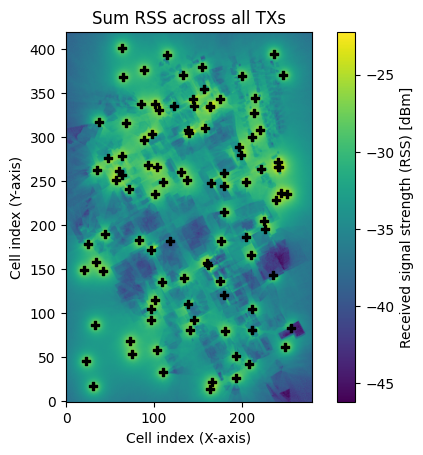

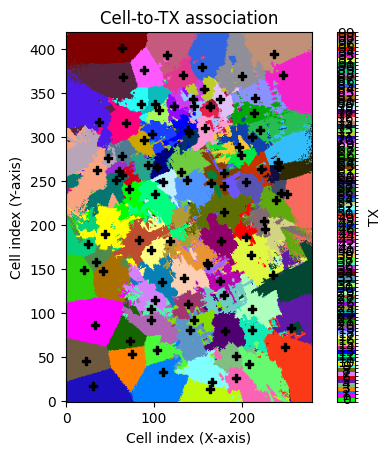

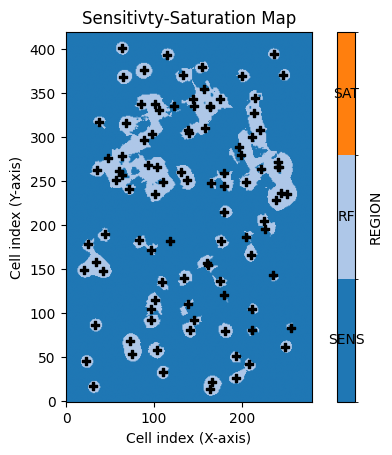

| Type   |   RX energy (dbm) |   DC energy (dbm) |   time (s) |
|--------+-------------------+-------------------+------------|
| Mean   |          -33.4981 |               -30 |        162 |
| Q1     |          -35.542  |               -30 |        162 |
| Median |          -33.6237 |               -30 |        162 |
| Q3     |          -31.2257 |               -30 |        162 |


| Not enough RF   | Charging   | Saturation   |
|-----------------+------------+--------------|
| 84.370%         | -84.370%   | 100.000%     |


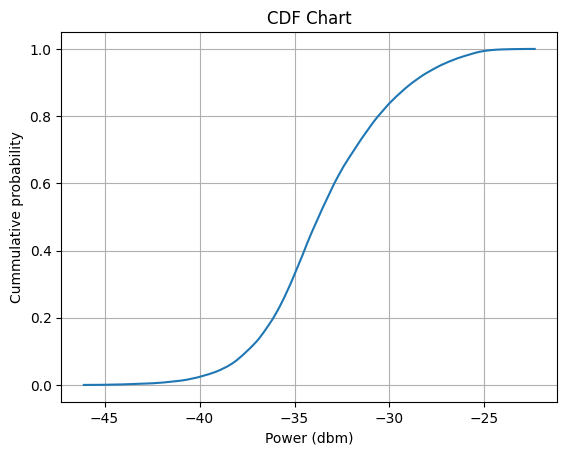

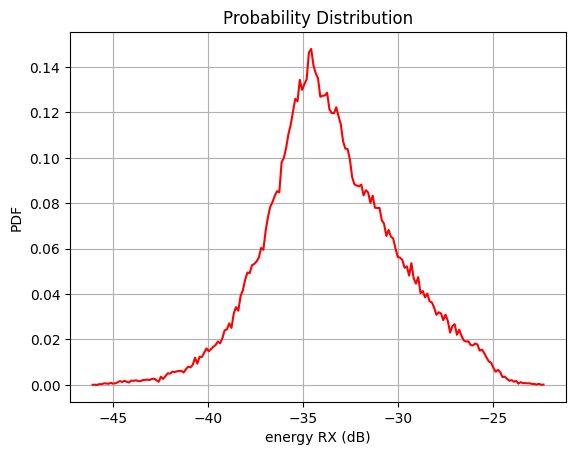

In [9]:
current_scene.frequency = 3e9
#num_cols = 64
current_scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

transmitters = []
positions_array = []

num_transmitters = 100
for i in range(num_transmitters):
    pos = [random.randint(-600, 600), random.randint(-1000, 1000), 25]
    num_iterations = 0
    while(not check_position_valid(pos, positions_array)):
        pos = [random.randint(-600, 600), random.randint(-1000, 1000), 25] 
        num_iterations += 1
        if(num_iterations > 100):
            print(f"to many iterations at transmitter #{i}")
            break
    
    positions_array.append(pos)
    transmitters.append(Transmitter(name=f"tx{i}", position=pos, display_radius=10, power_dbm=43))
    transmitters[-1].orientation = (random.random()*365.0, 0, 0) 
    current_scene.add(transmitters[-1])
    
rm_solver = RadioMapSolver()
rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1400, 2100],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical



radio_functions.show_sum(rm, metric="rss")
radio_functions.show_association_more_colours(rm)
radio_functions.show_DC_regions(rm, metric="rss")

cdf_values = radio_functions.sum_cdf(rm, metric="rss");
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()
metrics.display_cdf_and_pdf(cdf_values[2])
current_scene.preview(radio_map=rm);

In [ ]:
#Using the scene from above we run 10 tests to find the best positions we can find
num_simulations = 1
min_sensitivity_percentage = 1
min_saturation_percentage = 1
best_sens_radio_map = rm
best_sat_radio_map = rm
best_positions = []
best_orientations = []

for i in range(num_simulations):
    positions_array = []

    for j in range(num_transmitters):
        pos = [random.randint(-600, 600), random.randint(-1000, 1000), 25]
        num_iterations = 0
        while(not check_position_valid(pos, positions_array)):
            pos = [random.randint(-600, 600), random.randint(-1000, 1000), 25] 
            num_iterations += 1
            if(num_iterations > 100):
                print(f"to many placing iterations at transmitter #{i}")
                break
        
        positions_array.append(pos)
        transmitters[j].position = pos
        transmitters[j].orientation = (random.random()*365.0, 0, 0) 

    rm = rm_solver(current_scene,
        max_depth=30,           # Maximum number of ray scene interactions
        samples_per_tx=10**7 , # If you increase: less noise, but more memory required
        cell_size=(5, 5),      # Resolution of the radio map
        center=[0, 10, 1],      # Center of the radio map
        size=[1400, 2100],       # Total size of the radio map
        orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    cdf_values = radio_functions.sum_cdf(rm, metric="rss");
    metrics = radio_functions.calculate_metrics_from_cdf(cdf_values);
    #print(f"sens percentage is {metrics.sens_percentage*100:.3f}%")
    if(metrics.sens_percentage < min_sensitivity_percentage):
        min_sensitivity_percentage = metrics.sens_percentage
        best_sens_radio_map = rm
        best_positions = positions_array.copy()
        best_orientations = []
        for k in range(len(transmitters)):
            best_orientations.append(transmitters[k].orientation)


    if(metrics.sat_percentage < min_saturation_percentage):
        min_saturation_percentage = metrics.sat_percentage
        best_sat_radio_map = rm

    
print("Sensitivity:")
radio_functions.show_sum(best_sens_radio_map, metric="rss")
radio_functions.show_association_more_colours(best_sens_radio_map)
radio_functions.show_DC_regions(best_sens_radio_map, metric="rss")

cdf_values = radio_functions.sum_cdf(best_sens_radio_map, metric="rss")
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()

#print("\n\n\nSaturation:")
#radio_functions.show_sum(best_sat_radio_map, metric="rss")
#radio_functions.show_association_more_colours(best_sat_radio_map)
#radio_functions.show_DC_regions(best_sat_radio_map, metric="rss")

#cdf_values = radio_functions.sum_cdf(best_sat_radio_map, metric="rss")
#metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
#metrics.print_related_values()

In [ ]:
#Time simulation
#Samples 10 random positions and generates time-energy charts based on their charging

simulation_time = 40 #Total time of simulation in seconds
delta_time = 0.25 #Time between steps (in seconds)
rotation_speed = 10 #Speed of rotation (in deg/s)

num_sample_positions = 10
x_size = 280
y_size = 420

#Update positions and orientation for maximum
for i in range(len(best_orientations)):
    transmitters[i].position = best_positions[i]
    transmitters[i].orientation = best_orientations[i]

#Generate sampling positions
sample_cell_positions = []
stored_voltage_array = [] 
for i in range(num_sample_positions):
    sample_cell_positions.append([random.randrange(0, 280), random.randrange(0, 420)])
    stored_voltage_array.append([0])

#Plotting reciever positions
for i in range(num_sample_positions):
    position = mi.Point3f([sample_cell_positions[i][0], sample_cell_positions[i][1], 1])
    position *= 5
    position -= mi.Point3f([700, 1050, 0]) #Center at middle of array
    position += mi.Point3f([0, 10, 0]) #Add offset of radio_map

    current_scene.add(Receiver(name=f"rx_{i}", position = position))


rm = rm_solver(current_scene,
        max_depth=30,           # Maximum number of ray scene interactions
        samples_per_tx=10**7 , # If you increase: less noise, but more memory required
        cell_size=(5, 5),      # Resolution of the radio map
        center=[0, 10, 1],      # Center of the radio map
        size=[1400, 2100],       # Total size of the radio map
        orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


Artists = []
fig, [ax, ax2] = plt.subplots(1, 2)
fig.subplots_adjust(0.125, 0.1,0.9, 0.9, 0.5, 0.2)
radio_functions.sum_animation_setup(rm, metric="rss", show_rx=True, fig=fig, ax = ax)
ax2.set_ylabel("Stored Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Samples Positions Collected Voltage")


x_axis = [0]

for time_step in range(int(simulation_time/delta_time)):
    
    #Solve radio map
    rm = rm_solver(current_scene,
        max_depth=30,           # Maximum number of ray scene interactions
        samples_per_tx=10**7 , # If you increase: less noise, but more memory required
        cell_size=(5, 5),      # Resolution of the radio map
        center=[0, 10, 1],      # Center of the radio map
        size=[1400, 2100],       # Total size of the radio map
        orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    sum_radio_map = radio_functions.sum_radio_map(rm, metric="rss")

    image = radio_functions.sum_animation(rm, metric="rss", axis=ax)
    lines = []

    for i in range(num_sample_positions):
        line = ax2.plot(x_axis, stored_voltage_array[i], color=mpl.colormaps['tab20'].colors[i], linewidth=3.0) 
        lines += line

    lines.append(image)
    Artists.append(lines)
    x_axis.append(time_step * delta_time)

    for i in range(num_sample_positions):
        #For some reason the radio map has x and y reversed
        recieved_signal_strength = sum_radio_map[sample_cell_positions[i][1]][sample_cell_positions[i][0]]
        recieved_DC_power = radio_functions.DC_power_recieved(recieved_signal_strength)
        
        #Creates a new data point for the stored voltage at this time
        new_voltage = radio_functions.calculate_final_voltage(recieved_DC_power, delta_time, stored_voltage_array[i][-1])
        stored_voltage_array[i].append(new_voltage)

    
    #rotate transmitters 
    deg_rotation = delta_time * rotation_speed * (2 * math.pi/180)
    for i in range(num_transmitters):
        transmitters[i].orientation[0] += deg_rotation


anim = animation.ArtistAnimation(fig=fig, artists=Artists, interval=80)
anim.save("Test2_Animations/tr39801_ROTATING_Antennas.gif", writer="pillow")
plt.show()



In [ ]:
num_cols = 8
current_scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=num_cols, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="hw_dipole",
                             polarization="V")

simulation_time = 40 #Total time of simulation in seconds
delta_time = 0.25 #Time between steps (in seconds)
rotation_speed = 10 #Speed of rotation (in deg/s)

num_sample_positions = 10
x_size = 280
y_size = 420

for i in range(len(best_orientations)):
    transmitters[i].position = best_positions[i]
    transmitters[i].orientation = best_orientations[i]

Artists = []
fig, [ax, ax2] = plt.subplots(1, 2)
fig.subplots_adjust(0.125, 0.1,0.9, 0.9, 0.5, 0.2)
radio_functions.sum_animation_setup(rm, metric="rss", show_rx=True, fig=fig, ax = ax)
ax2.set_ylabel("Stored Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Samples Positions Collected Voltage")

#x_axis for the collected energy charts
x_axis = [0]

stored_voltage_array = [] 
for i in range(num_sample_positions):
    stored_voltage_array.append([0])

for time_step in range(int(simulation_time/delta_time)):
    
    #Solve radio map
    rm = rm_solver(current_scene,
        max_depth=30,           # Maximum number of ray scene interactions
        samples_per_tx=10**7 , # If you increase: less noise, but more memory required
        cell_size=(5, 5),      # Resolution of the radio map
        center=[0, 10, 1],      # Center of the radio map
        size=[1400, 2100],       # Total size of the radio map
        orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    sum_radio_map = radio_functions.sum_radio_map(rm, metric="rss")

    image = radio_functions.sum_animation(rm, metric="rss", axis=ax)
    lines = []

    for i in range(num_sample_positions):
        line = ax2.plot(x_axis, stored_voltage_array[i], color=mpl.colormaps['tab20'].colors[i], linewidth=3.0) 
        lines += line

    lines.append(image)
    Artists.append(lines)
    x_axis.append(time_step * delta_time)

    for i in range(num_sample_positions):
        #For some reason the radio map has x and y reversed
        recieved_signal_strength = sum_radio_map[sample_cell_positions[i][1]][sample_cell_positions[i][0]]
        recieved_DC_power = radio_functions.DC_power_recieved(recieved_signal_strength)
        
        #Creates a new data point for the stored power at this time
        new_voltage = radio_functions.calculate_final_voltage(recieved_DC_power, delta_time, stored_voltage_array[i][-1])
        stored_voltage_array[i].append(new_voltage)

    
    #rotate transmitters 
    deg_rotation = delta_time * rotation_speed * (2 * math.pi/180)
    for i in range(num_transmitters):
        transmitters[i].orientation[0] += deg_rotation


anim = animation.ArtistAnimation(fig=fig, artists=Artists, interval=80)
anim.save("Test2_Animations/linear_array_ROTATING_Antennas.gif", writer="pillow")
plt.show()

In [ ]:
num_cols = 8
current_scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=num_cols, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="hw_dipole",
                             polarization="V")

simulation_time = 40 #Total time of simulation in seconds
delta_time = 0.25 #Time between steps (in seconds)
rotation_speed = 10 #Speed of rotation (in deg/s)

num_sample_positions = 10
x_size = 280
y_size = 420

for i in range(len(best_orientations)):
    transmitters[i].position = best_positions[i]
    transmitters[i].orientation = best_orientations[i]

Artists = []
fig, [ax, ax2] = plt.subplots(1, 2)
fig.subplots_adjust(0.125, 0.1,0.9, 0.9, 0.5, 0.2)
radio_functions.sum_animation_setup(rm, metric="rss", show_rx=True, fig=fig, ax = ax)
ax2.set_ylabel("Stored Voltage (V)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Samples Positions Collected Voltage")

#x_axis for the collected energy charts
x_axis = [0]

stored_voltage_array = [] 
for i in range(num_sample_positions):
    stored_voltage_array.append([0])

total_rotation = 0
precoding_vector = radio_functions.compute_precoding_vector(num_cols=num_cols, steering_angle=total_rotation)
for time_step in range(int(simulation_time/delta_time)):
    
    #Solve radio map
    rm = rm_solver(current_scene,
        max_depth=30,           # Maximum number of ray scene interactions
        samples_per_tx=10**7 , # If you increase: less noise, but more memory required
        cell_size=(5, 5),      # Resolution of the radio map
        precoding_vec=precoding_vector,
        center=[0, 10, 1],      # Center of the radio map
        size=[1400, 2100],       # Total size of the radio map
        orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    sum_radio_map = radio_functions.sum_radio_map(rm, metric="rss")

    image = radio_functions.sum_animation(rm, metric="rss", axis=ax)
    lines = []

    for i in range(num_sample_positions):
        line = ax2.plot(x_axis, stored_voltage_array[i], color=mpl.colormaps['tab20'].colors[i], linewidth=3.0) 
        lines += line

    lines.append(image)
    Artists.append(lines)
    x_axis.append(time_step * delta_time)

    for i in range(num_sample_positions):
        #For some reason the radio map has x and y reversed
        recieved_signal_strength = sum_radio_map[sample_cell_positions[i][1]][sample_cell_positions[i][0]]
        recieved_DC_power = radio_functions.DC_power_recieved(recieved_signal_strength)
        
        #Creates a new data point for the stored power at this time
        new_voltage = radio_functions.calculate_final_voltage(recieved_DC_power, delta_time, stored_voltage_array[i][-1])
        stored_voltage_array[i].append(new_voltage)

    
    #rotate transmitters 
    total_rotation += delta_time * rotation_speed * (2 * math.pi/180)
    precoding_vector = radio_functions.compute_precoding_vector(num_cols=num_cols, steering_angle=total_rotation)
        


anim = animation.ArtistAnimation(fig=fig, artists=Artists, interval=80)
anim.save("Test2_Animations/linear_array_Beamforming_Antennas.gif", writer="pillow")
plt.show()